# 01. Portrait du corpus

Ce premier notebook présente le corpus et ses principales caractéristiques structurelles. Le **corpus** désigne ici l’ensemble des unités textuelles (tweets et interventions parlementaires) collectées et annotées pour l’analyse. On travaille avec 10 774 textes produits par 459 députés français entre octobre 2023 et janvier 2026. Les textes proviennent de deux sources : les tweets publiés sur X (9 135) et les interventions en séance à l’Assemblée nationale (1 639).

Les députés sont regroupés en **blocs politiques** — Gauche radicale, Gauche modérée, Centre / Majorité, Droite — selon leur groupe parlementaire, afin de comparer les discours par famille politique. Le corpus est fortement **déséquilibré** : la répartition du volume de production varie nettement entre blocs, la Gauche radicale produisant 63,5 % des textes, loin devant la Droite (13,7 %), le Centre (13,8 %) et la Gauche modérée (9,0 %). Ce déséquilibre reflète une réalité empirique — les députés de gauche s’expriment davantage sur ce conflit, surtout sur Twitter — mais il a des conséquences sur la puissance statistique des comparaisons et doit être pris en compte dans les analyses.

## Setup et configuration

Les bibliothèques et les paramètres communs sont chargés.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## Chargement du corpus

Le corpus principal est chargé à partir des données annotées. Chaque enregistrement comprend le texte, la date, le bloc politique et le score de positionnement discursif.

In [2]:
from config import CORPUS_V3
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))
print(f"{len(df):,} textes, {df['author'].nunique()} députés")

10,774 textes, 459 députés


## Fig 01 : Volume mensuel empilé par bloc

Le graphique suivant représente l’évolution mensuelle du volume de textes produits par chaque bloc politique. Les ordonnées empilées permettent de visualiser à la fois la contribution de chaque bloc et le volume total au fil du temps.

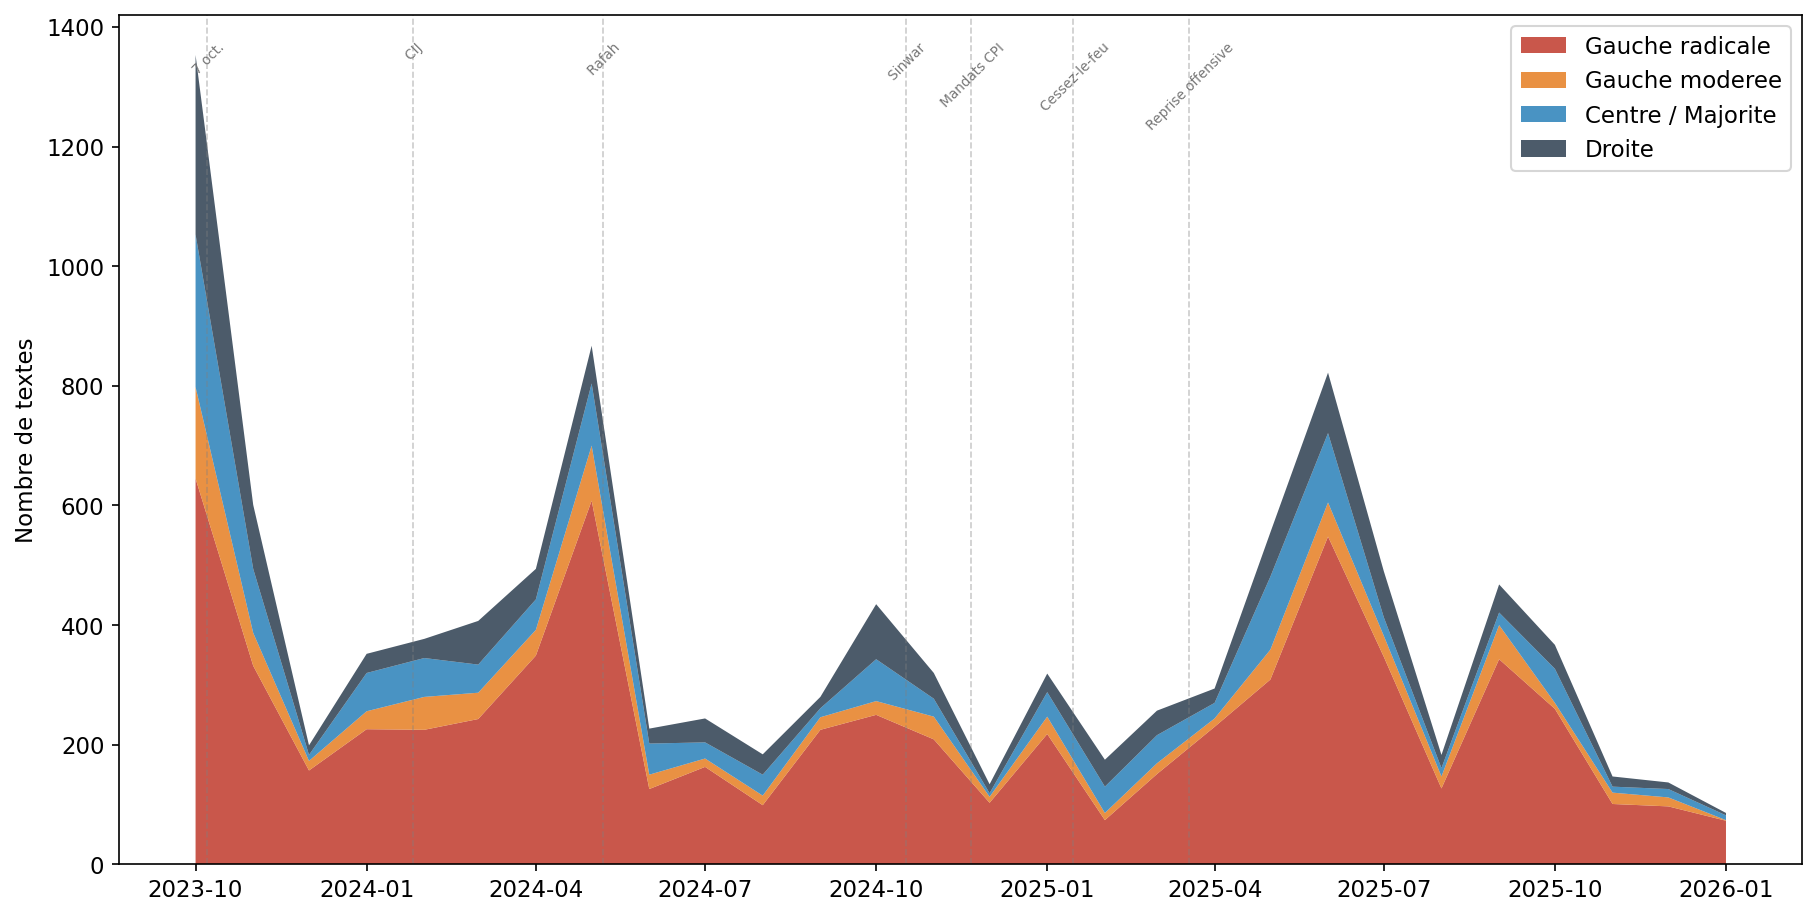

In [3]:
vol = df.groupby(['month', 'bloc']).size().unstack(fill_value=0)
vol = vol.reindex(columns=[b for b in BLOC_ORDER if b in vol.columns])
vol['month_ts'] = pd.to_datetime(vol.index + '-01')
vol.to_csv(RES_DIR / 'volume_mensuel.csv', index=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(vol['month_ts'], *[vol[b] for b in BLOC_ORDER if b in vol.columns],
             labels=[b for b in BLOC_ORDER if b in vol.columns],
             colors=[BLOC_COLORS[b] for b in BLOC_ORDER if b in vol.columns], alpha=0.85)
add_events(ax)
ax.legend(loc='upper right')
ax.set_ylabel('Nombre de textes')
save('fig01_volume_mensuel_empile')

La domination constante de la Gauche radicale se confirme ; les pics de volume coïncident avec les événements marquants (CIJ, Rafah, mandats CPI). La ventilation par arène distingue la production sur Twitter de celle à l’Assemblée nationale.

## Fig 02 : Volume par bloc et par arène

## Biais d'activité structurel

Les parlementaires les plus actifs sur Twitter contribuent de façon disproportionnée au corpus. Mesure du biais : nombre de tweets par député et par bloc (arène Twitter uniquement).

Ratio tweets/député GR/Droite : 6.16


C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_4956\1180606880.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


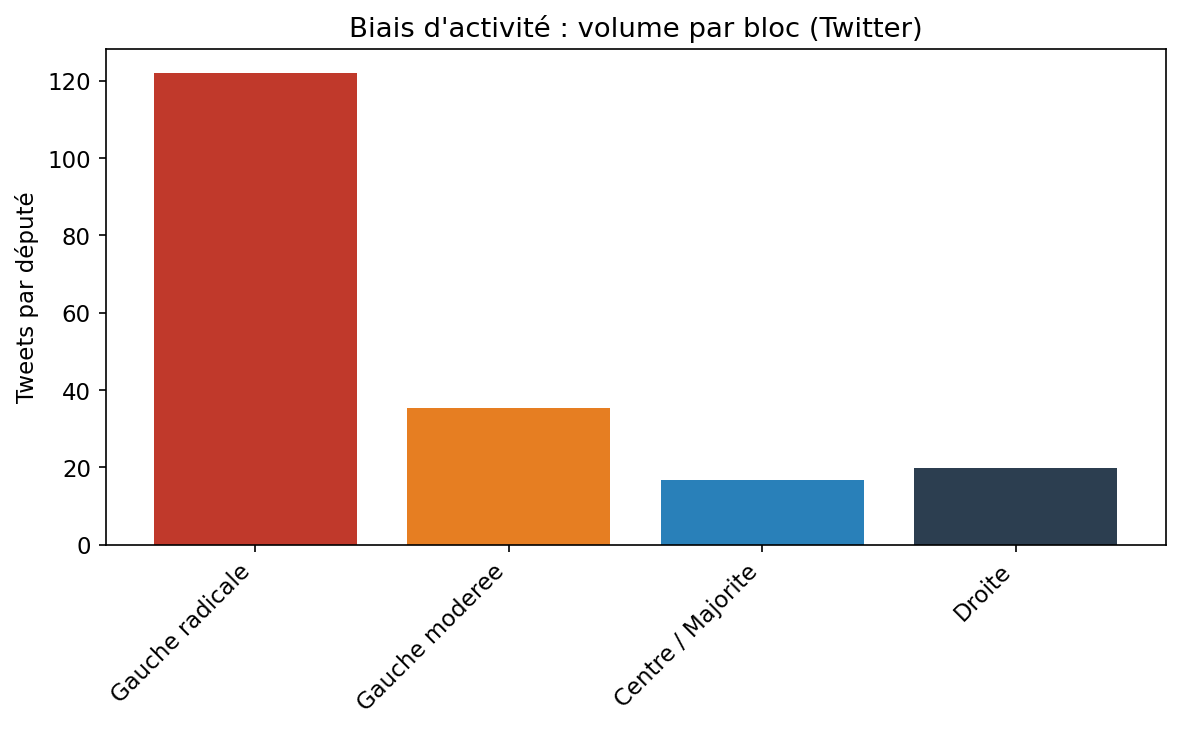

In [4]:
df_tw = df[(df['arena'] == 'Twitter') | (df.get('source', '') == 'twitter')]
if len(df_tw) > 0:
    activity = df_tw.groupby('bloc').agg(n_tweets=('author', 'count'), n_deputies=('author', 'nunique')).reset_index()
    activity['tweets_per_deputy'] = activity['n_tweets'] / activity['n_deputies']
    activity = activity[activity['bloc'].isin(BLOC_ORDER)]
    gr_val = activity[activity['bloc'] == 'Gauche radicale']['tweets_per_deputy'].values
    dr_val = activity[activity['bloc'] == 'Droite']['tweets_per_deputy'].values
    ratio_gr_dr = gr_val[0] / dr_val[0] if len(gr_val) > 0 and len(dr_val) > 0 and dr_val[0] > 0 else np.nan
    print(f"Ratio tweets/député GR/Droite : {ratio_gr_dr:.2f}" if not np.isnan(ratio_gr_dr) else "Données insuffisantes")
    activity.to_csv(RES_DIR / 'activity_bias_by_bloc.csv', index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    order = [b for b in BLOC_ORDER if b in activity['bloc'].values]
    sub = activity[activity['bloc'].isin(order)].set_index('bloc').reindex(order)
    ax.bar(range(len(order)), sub['tweets_per_deputy'].values, color=[BLOC_COLORS.get(b, '#888') for b in order])
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_ylabel('Tweets par député')
    ax.set_title('Biais d\'activité : volume par bloc (Twitter)')
    plt.tight_layout()
    save('fig55_activity_bias')

## Visibilité et polarisation

Les parlementaires les plus visibles (tweets × engagement) sont-ils en moyenne plus modérés ou plus extrêmes ? Test du paradoxe visibilité–polarisation sur le conflit Gaza.

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_4956\1938420962.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


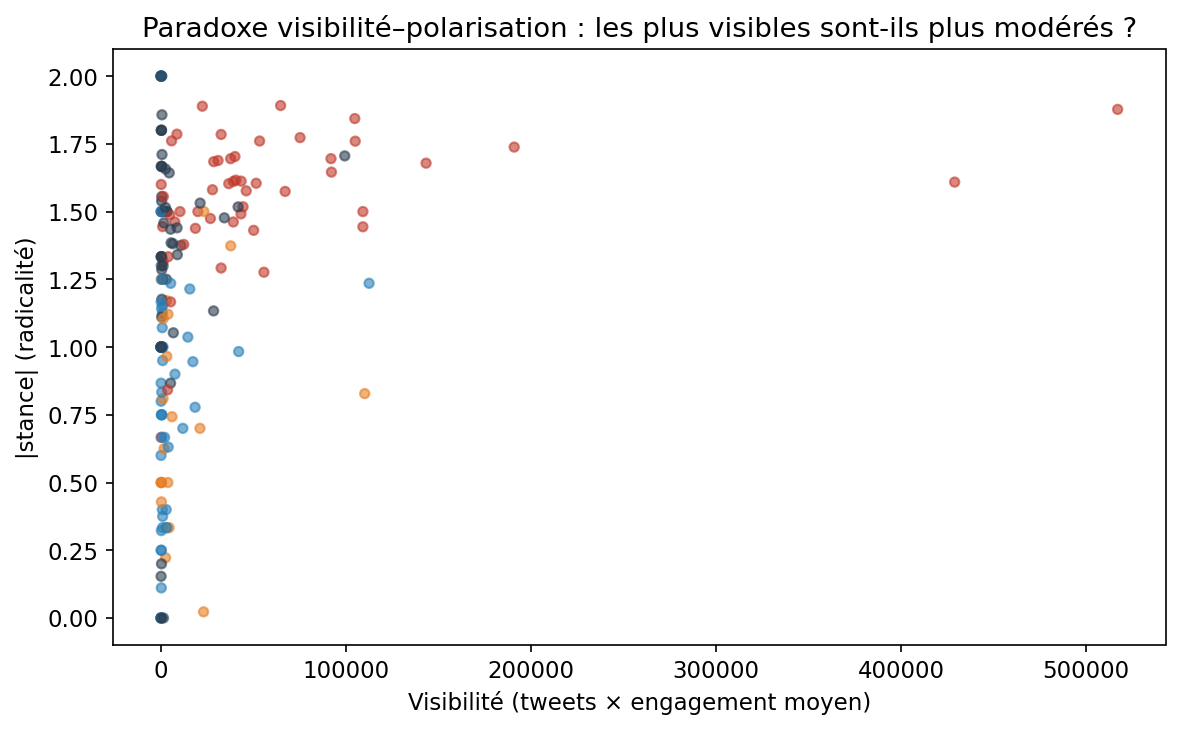

In [5]:
if len(df_tw) > 0:
    if 'engagement' not in df_tw.columns and all(c in df_tw.columns for c in ['retweets', 'likes', 'replies']):
        df_tw = df_tw.copy()
        df_tw['engagement'] = df_tw['retweets'] + df_tw['likes'] + df_tw['replies']
    if 'engagement' in df_tw.columns:
        dep_vis = df_tw.groupby('author').agg(
            n_tweets=('author', 'count'),
            mean_engagement=('engagement', 'mean'),
            stance_mean=('stance_v3', 'mean'),
            bloc=('bloc', 'first')
        ).reset_index()
        dep_vis['visibility_proxy'] = dep_vis['n_tweets'] * dep_vis['mean_engagement']
        dep_vis['stance_abs'] = dep_vis['stance_mean'].abs()
        dep_vis = dep_vis[dep_vis['visibility_proxy'] > 0]
        if len(dep_vis) >= 10:
            dep_vis['quintile'] = pd.qcut(dep_vis['visibility_proxy'], 5, labels=False, duplicates='drop')
            quint_agg = dep_vis.groupby('quintile').agg(
                mean_abs_stance=('stance_abs', 'mean'),
                mean_stance=('stance_mean', 'mean'),
                n=('author', 'count')
            ).reset_index()
            quint_agg.to_csv(RES_DIR / 'visibility_paradox_quintiles.csv', index=False)

            fig, ax = plt.subplots(figsize=(8, 5))
            colors = dep_vis['bloc'].map(lambda b: BLOC_COLORS.get(b, '#888'))
            ax.scatter(dep_vis['visibility_proxy'], dep_vis['stance_abs'], c=colors, alpha=0.6, s=20)
            ax.set_xlabel('Visibilité (tweets × engagement moyen)')
            ax.set_ylabel('|stance| (radicalité)')
            ax.set_title('Paradoxe visibilité–polarisation : les plus visibles sont-ils plus modérés ?')
            plt.tight_layout()
            save('fig56_visibility_paradox')

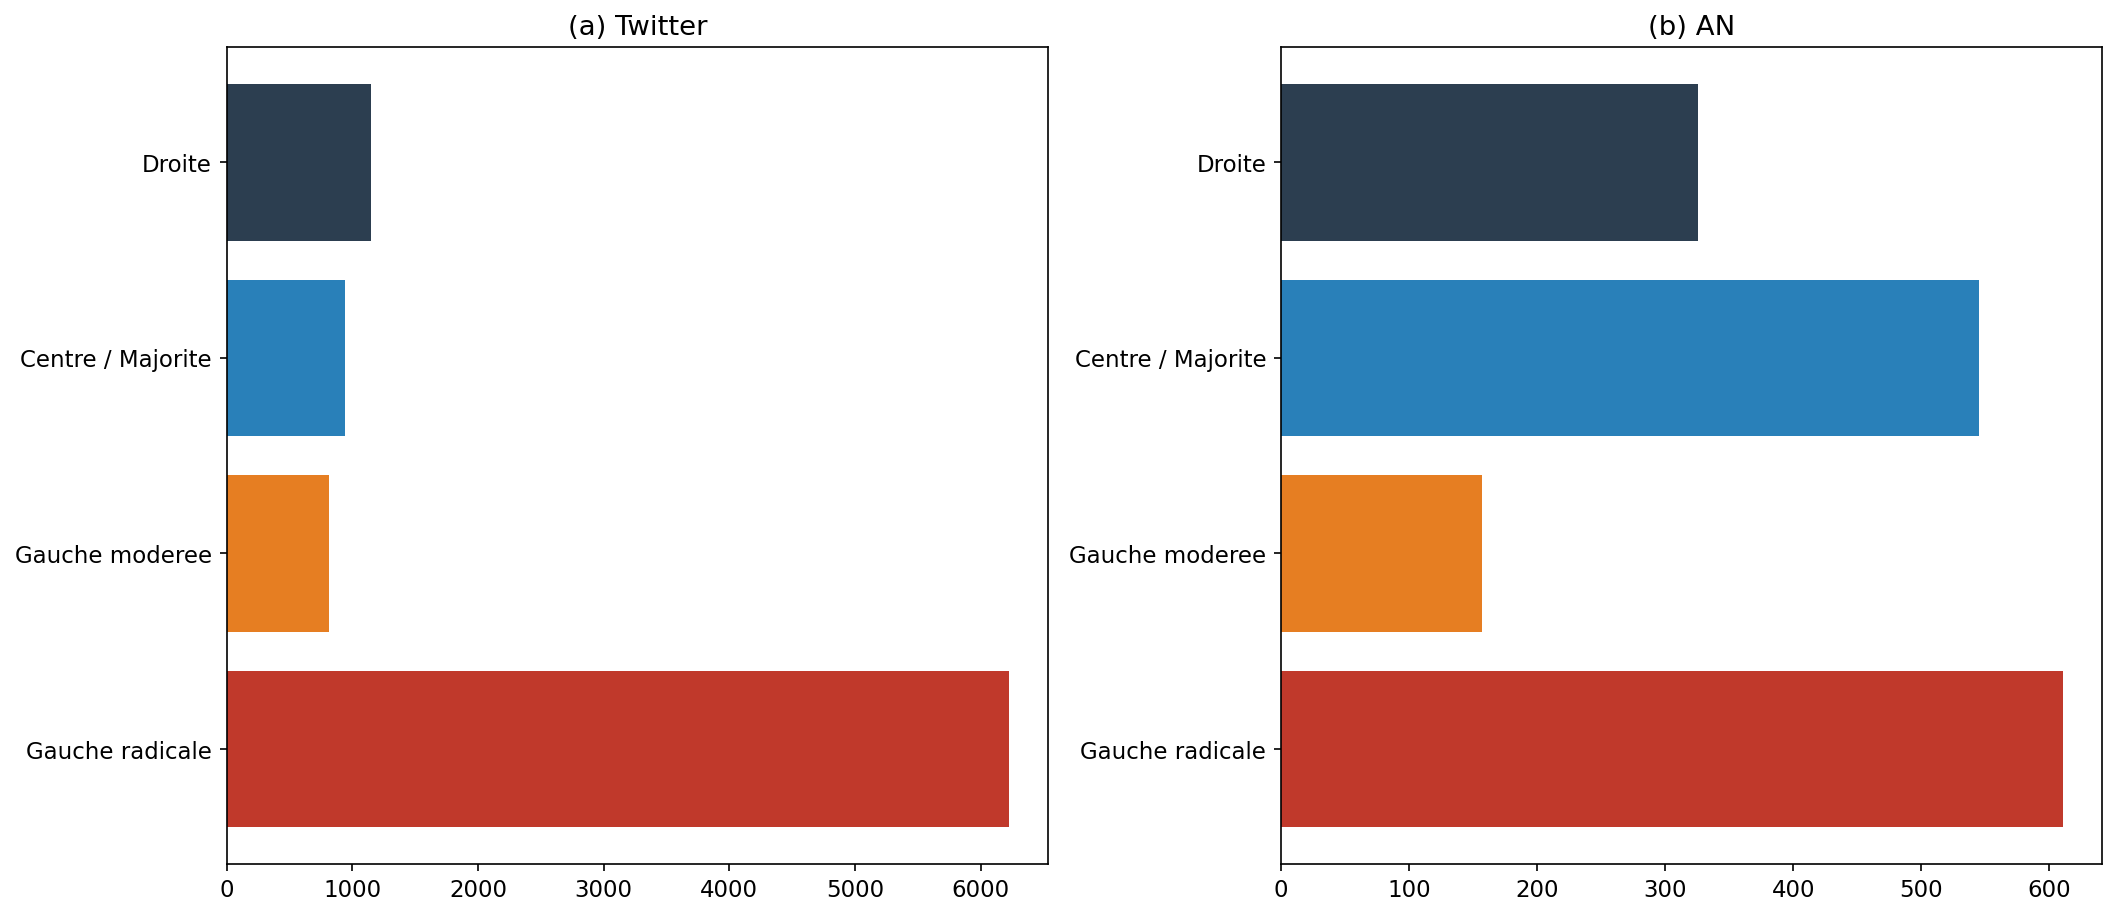

In [6]:
vol_arena = df.groupby(['bloc', 'arena']).size().unstack(fill_value=0)
vol_arena = vol_arena.reindex(BLOC_ORDER).dropna(how='all')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, arena in enumerate(['Twitter', 'AN']):
    if arena in vol_arena.columns:
        s = vol_arena[arena].reindex(BLOC_ORDER)
        axes[i].barh(s.index, s.values, color=[BLOC_COLORS.get(b,'#888') for b in s.index])
        axes[i].set_title(f'({chr(97+i)}) {arena}')
save('fig02_volume_par_arena')

## Fig 03 : Attrition

L’**attrition** désigne la diminution du nombre de députés produisant au moins un texte sur le conflit au fil du temps. Le nombre de députés actifs passe de 211 en octobre 2023 à 34 en janvier 2026 ; cette baisse peut refléter une moindre mobilisation sur le sujet ou un changement de calendrier politique.

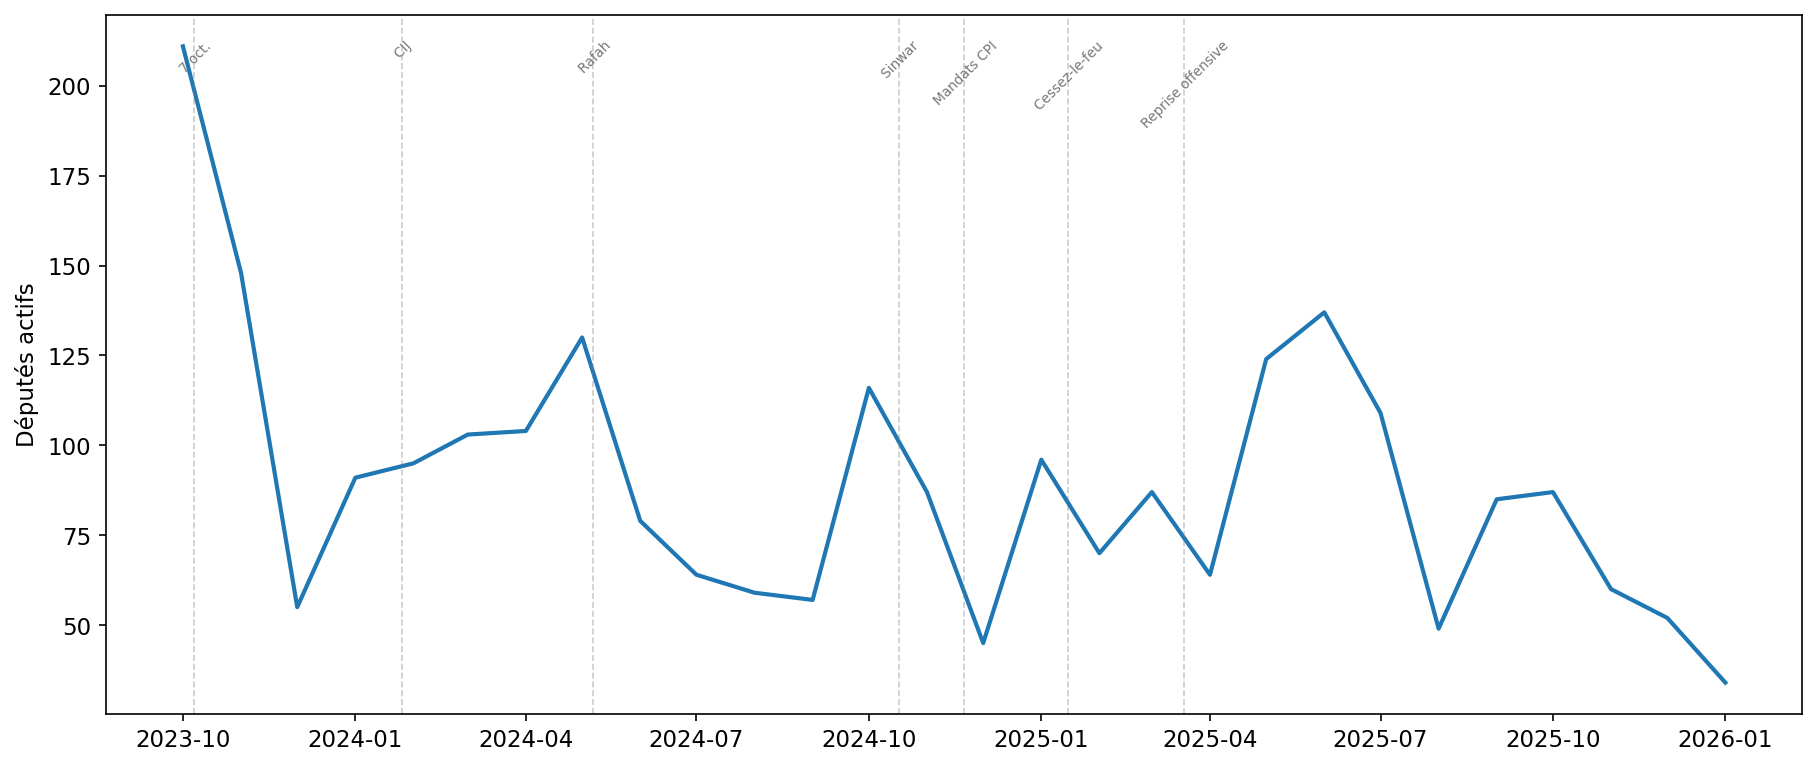

In [7]:
att = df.groupby('month').agg(n_deputes_actifs=('author','nunique'), n_textes=('author','count')).reset_index()
att['month_ts'] = pd.to_datetime(att['month'] + '-01')
att.to_csv(RES_DIR / 'attrition_mensuelle.csv', index=False)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(att['month_ts'], att['n_deputes_actifs'], lw=2)
add_events(ax)
ax.set_ylabel('Députés actifs')
save('fig03_attrition')

## Fig 04 : Déséquilibre par groupe politique

Le déséquilibre entre groupes parlementaires est marqué : LFI produit environ 4 500 textes, le RN environ 800, Renaissance environ 600. Ces écarts structurent l’interprétation des tendances agrégées par bloc.

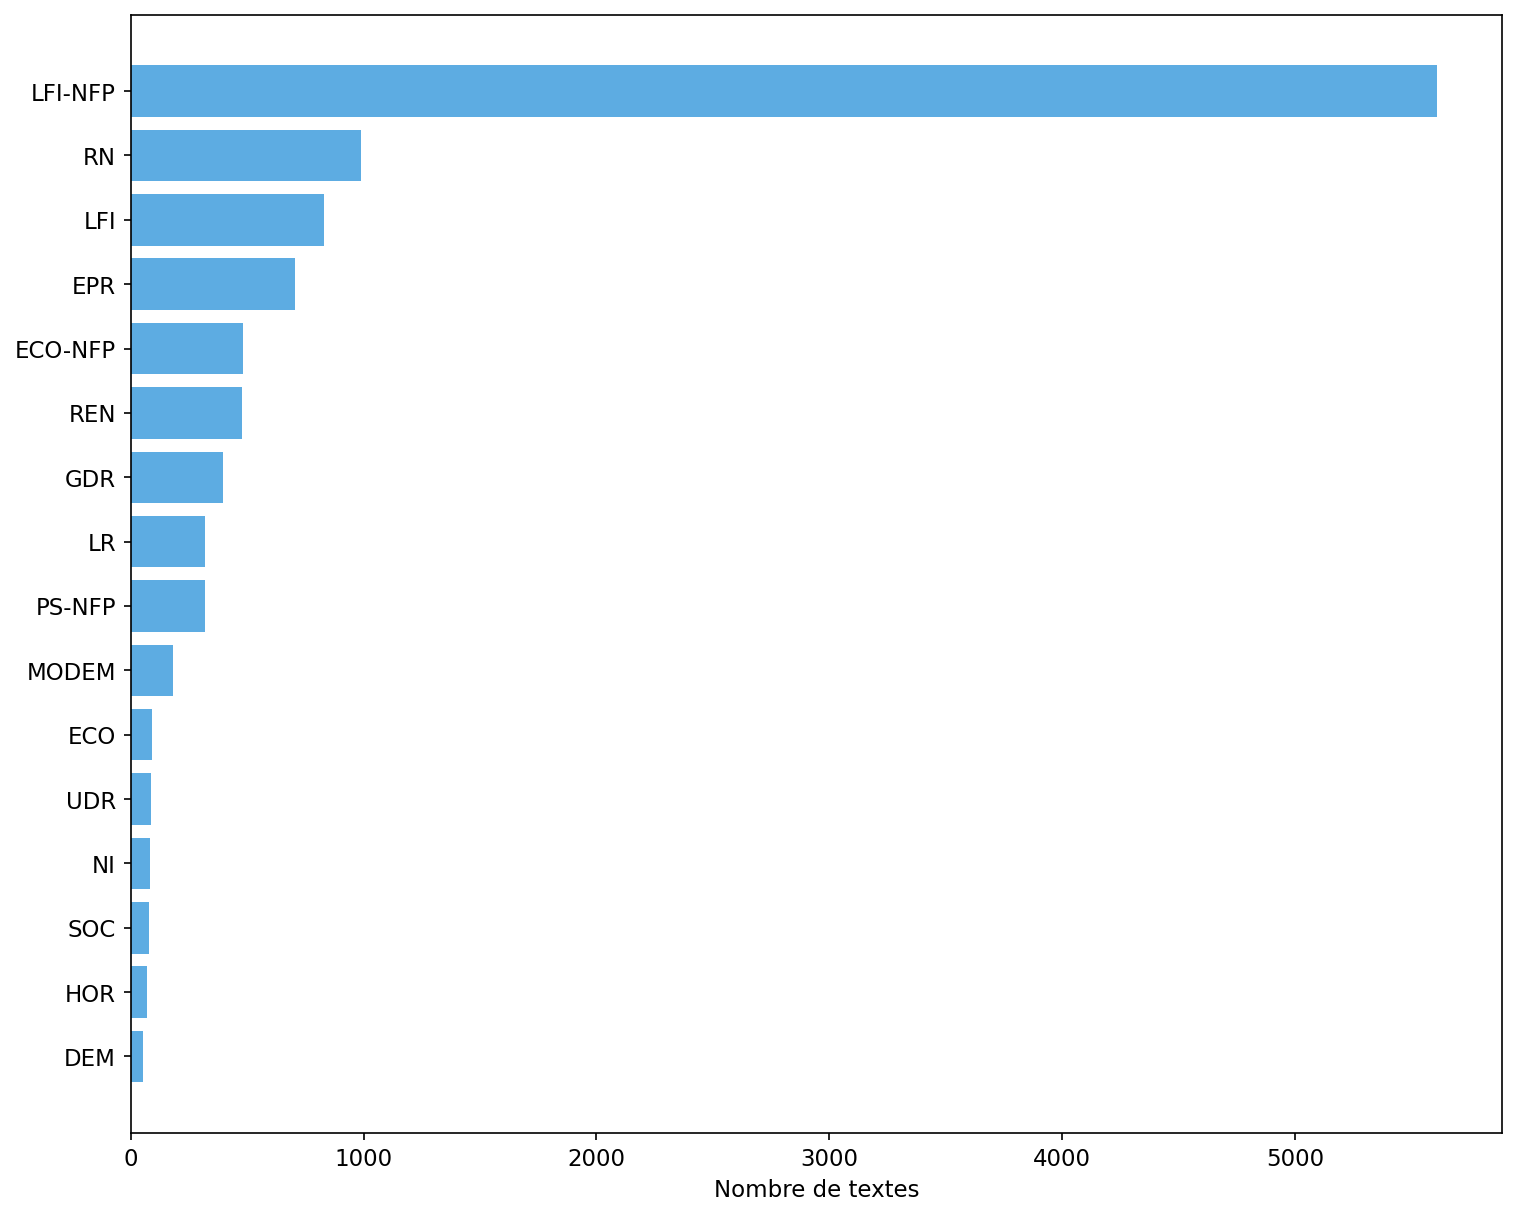

In [8]:
grp = df.groupby('group').size().sort_values(ascending=True)
grp.to_csv(RES_DIR / 'volume_par_groupe.csv')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(grp.index.astype(str), grp.values, color='#3498db', alpha=0.8)
ax.set_xlabel('Nombre de textes')
save('fig04_desequilibre_groupe')

## Fig 05 : Répartition du positionnement discursif par bloc

Le **positionnement discursif** (ou score de positionnement) est une variable continue annotée par modèle de langage, mesurant la tonalité du texte par rapport au conflit, de -2 (très favorable à Israël) à +2 (très favorable à la Palestine / cessez-le-feu). Les violons montrent la bimodalité du Centre et l’unimodalité des extrêmes : la distribution des scores varie selon la famille politique.

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_4956\261961966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='bloc', y='stance_v3', order=BLOC_ORDER,


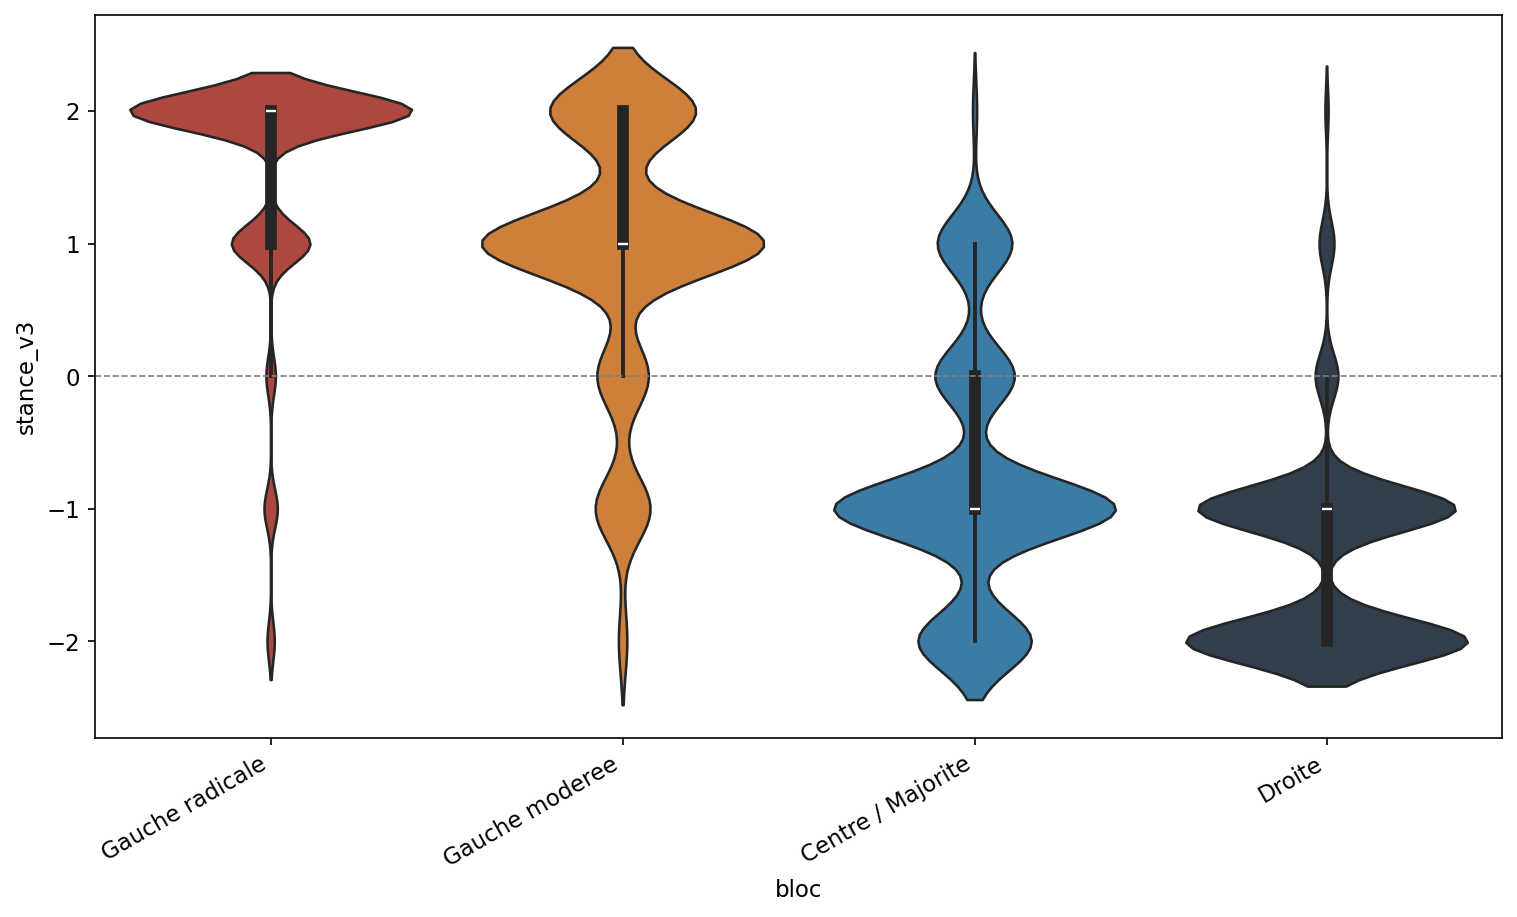

In [9]:
df_plot = df[df['bloc'].isin(BLOC_ORDER)].copy()
df_plot['bloc'] = pd.Categorical(df_plot['bloc'], categories=BLOC_ORDER)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_plot, x='bloc', y='stance_v3', order=BLOC_ORDER,
               palette=BLOC_COLORS)
ax.axhline(0, color='grey', ls='--', lw=0.8)
plt.xticks(rotation=30, ha='right')
save('fig05_stance_violin')

La domination de la Gauche radicale et les pics de volume liés aux événements (CIJ, Rafah, mandats CPI) sont confirmés.